# **Data Mining 1 – CA2**  
### **Predictive Modelling with World Bank & UN HDI Data** 

**Student:** Berkay Eren <br>
**Module:** Data Mining 1 <br>
**Lecturer:** Dr Bernard Butler  

---

## **Introduction**

In this notebook, I use international development data from the **World Bank** and the **UN Human Development Report** to:

1. Predict **life expectancy at birth** using economic and social indicators (regression).
2. Predict a country’s **Human Development Index (HDI) group** using those indicators (classification).
3. Discover **natural groupings of countries** and compare them with the official HDI groups (clustering).

My aim is to go through the full data mining process:

- Explore and understand the data (EDA),
- Prepare a clean modelling dataset,
- Build and evaluate supervised models (regression & classification),
- Apply unsupervised learning (clustering),
- Interpret the results.

Throughout the notebook, I will try to explain my decisions and trade-offs, especially around data preparation and model choice. I hope the notebook will be readable as a **report** even if the reader is not focused on the code.

## **Setup and Data Loading**

I start by importing the main libraries for:

- **pandas / numpy** for data handling,
- **matplotlib / seaborn** for plots,
- **scikit-learn** for modelling and evaluation.

Next, I load the four files provided for the assignment:

- `worldBank_Data.csv` – economic & social indicators by country and year.
- `HDI_by_country.csv` – HDI score and HDI class by country.
- `HDR25_Statistical_Annex_HDI_Table.xlsx` – additional UN HDI details.
- `worldBank_SeriesMetadata.xlsx` – metadata describing each World Bank indicator.


In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid")

# Load datasets
wb = pd.read_csv("data/worldBank_Data.csv")
hdi = pd.read_csv("data/HDI_by_country.csv")
hdi_table = pd.read_excel("data/HDR25_Statistical_Annex_HDI_Table.xlsx")
meta = pd.read_excel("data/worldBank_SeriesMetadata.xlsx")

## **EDA Pass 1: First Look at the Data** 

In this first pass I want to understand the structure of the four files provided for the assignment.  
I do not clean anything yet. My aim is to see what each file contains, how the information is organised, and what role each file will play later.

The two main files for modelling are:

• `worldBank_Data.csv`, which holds all the economic and social indicators by country and year  
• `HDI_by_country.csv`, which holds the HDI score and the HDI class for each country

The other two files help with interpretation:

• `HDR25_Statistical_Annex_HDI_Table.xlsx`, which gives extra information about HDI and its components  
• `worldBank_SeriesMetadata.xlsx`, which explains what each World Bank indicator measures

In this step I check the structure of each file so I know what the rows represent, how the columns are arranged, and what kind of preparation work will be needed in the next pass.


In [317]:
wb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16763 entries, 0 to 16762
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   16760 non-null  object
 1   Country Code   16758 non-null  object
 2   Series Name    16758 non-null  object
 3   Series Code    16758 non-null  object
 4   2011 [YR2011]  16758 non-null  object
 5   2012 [YR2012]  16758 non-null  object
 6   2013 [YR2013]  16758 non-null  object
 7   2014 [YR2014]  16758 non-null  object
 8   2015 [YR2015]  16758 non-null  object
 9   2016 [YR2016]  16758 non-null  object
 10  2017 [YR2017]  16758 non-null  object
 11  2018 [YR2018]  16758 non-null  object
 12  2019 [YR2019]  16758 non-null  object
 13  2020 [YR2020]  16758 non-null  object
 14  2021 [YR2021]  16758 non-null  object
 15  2022 [YR2022]  16758 non-null  object
 16  2023 [YR2023]  16758 non-null  object
 17  2024 [YR2024]  16758 non-null  object
dtypes: object(18)
memory usage

In [318]:
wb.head()

,Country Name,Country Code,Series Name,Series Code,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Albania,ALB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,69.1,71.3,73.1,75.2,76.6,78.3,79.6,80.7,82,83.1,83.6,84.6,..,..
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.7,99.9,99.9,100,100,99.9,99.9,100,100,100,100,100,100,..
2,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.FE.ZS,22.6726112235836,..,..,33.5942341082043,..,..,38.1029578691588,..,..,..,45.6861097525436,..,..,41.1560488283684
3,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.MA.ZS,33.6646774405553,..,..,42.5196913972188,..,..,42.0435031953365,..,..,..,42.5851653897092,..,..,51.4508986584924
4,Albania,ALB,Adequacy of social protection and labor progra...,per_allsp.adq_pop_tot,..,27.9899243993596,..,..,..,..,..,..,..,..,..,..,..,..


In [319]:
hdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    193 non-null    object 
 1   HDI score  193 non-null    float64
 2   HDI Class  193 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.7+ KB


In [320]:
hdi.head()

,Country,HDI score,HDI Class
0,Iceland,0.972,Very High HDI
1,Norway,0.970,Very High HDI
2,Switzerland,0.970,Very High HDI
3,Denmark,0.962,Very High HDI
4,Germany,0.959,Very High HDI


In [321]:
hdi_table.head()

,Unnamed: 0,Table 1. Human Development Index and its components,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,SDG3,NaN,SDG4.3,NaN,SDG4.4,NaN,SDG8.5,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Human Development Index (HDI),NaN,Life expectancy at birth,NaN,Expected years of schooling,NaN,Mean years of schooling,NaN,Gross national income (GNI) per capita,NaN,GNI per capita rank minus HDI rank,NaN,HDI rank
4,HDI rank,Country,Value,NaN,(years),NaN,(years),NaN,(years),NaN,(2021 PPP $),NaN,NaN,NaN,NaN


In [322]:
meta.head()

,Code,License Type,Indicator Name,Short definition,Long definition,Source,Topic,Dataset,Unit of measure,Periodicity,...,Development relevance,Limitations and exceptions,Other notes,License URL,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,EG.CFT.ACCS.ZS,CC BY-4.0,Access to clean fuels and technologies for coo...,Access to clean fuels and technologies for coo...,Access to clean fuels and technologies for coo...,"Tracking SDG 7: The Energy Progress Report, In...",Environment: Energy production & use,WDI,% (share) of population,Annual,...,NaN,NaN,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
1,EG.ELC.ACCS.ZS,CC BY-4.0,Access to electricity (% of population),Access to electricity is the percentage of pop...,Access to electricity is the percentage of pop...,"SDG 7.1.1 Electrification Dataset, World Bank ...",Environment: Energy production & use,WDI,% (share) of population,Annual,...,Maintaining reliable and secure electricity se...,NaN,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
2,FX.OWN.TOTL.FE.ZS,CC BY-4.0,Account ownership at a financial institution o...,Account denotes the percentage of respondents ...,Account denotes the percentage of respondents ...,"Global Findex Database, World Bank (WB), uri: ...",Financial Sector: Access,WDI,NaN,Triennial,...,Financial inclusion allows individuals and fir...,NaN,Each economy is classified based on the classi...,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
3,FX.OWN.TOTL.MA.ZS,CC BY-4.0,Account ownership at a financial institution o...,Account denotes the percentage of respondents ...,Account denotes the percentage of respondents ...,"Global Findex Database, World Bank (WB), uri: ...",Financial Sector: Access,WDI,Weighted average,Triennial,...,financial inclusion is a key pillar to green f...,NaN,Each economy is classified based on the classi...,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
4,per_allsp.adq_pop_tot,CC BY-4.0,Adequacy of social protection and labor progra...,Adequacy of social protection and labor progra...,Adequacy of social protection and labor progra...,ASPIRE: The Atlas of Social Protection - Indic...,Social Protection & Labor: Performance,WDI,% of Total,Annual,...,"By harmonizing survey data for 129 countries, ...",When interpreting ASPIRE performance indicator...,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN


### Findings from EDA Pass 1

After checking all four files, I learned the following:

• The World Bank dataset is very large and stored in a long format. Each row represents one indicator for one country, and the year values run from 2011 to 2024.  
  All year columns are stored as text, and missing values appear as “..”. The year column names also include labels such as “[YR2011]”, so this file will need cleaning and reshaping before modelling.

• The HDI dataset is clean and simple. It has one row per country, with no missing values. This file is ready to merge once the World Bank data is prepared.

• The HDI statistical annex is not in a tidy format. It is mainly descriptive and is better used as background information rather than modelling data.

• The World Bank metadata describes the indicators in detail. It will be useful later when interpreting model results but is not needed during data preparation.

Overall, Pass 1 shows that the main preparation work will focus on cleaning and restructuring the World Bank dataset. Once that is done, I can merge it with the HDI data and start building models.

## **EDA Pass 2: Cleaning and Preparing the Dataset**

In this pass I prepare the World Bank dataset so I can analyse missingness and reshape it in the next steps.  
Since the file comes directly from the World Bank, it contains a few issues that must be fixed before I can work with it.

In this step I do the following:

• Convert the “..” entries into proper missing values (NaN).  
• Clean the year column names by removing the “[YRxxxx]” labels.  
• Convert all year columns to numeric values.  
• Remove duplicated rows, if any exist.  
• Check for missing country names or indicator codes.  
• Standardise text fields by stripping any trailing spaces.  
• Confirm that non-year columns look correct and consistent.

These tasks prepare the dataset for Pass 3, where I will analyse missingness and select a modelling year.

In [323]:
# working copy
wb_clean = wb.copy()

# replace ".." with NaN
wb_clean = wb_clean.replace("..", np.nan)

# strip extra spaces from text columns
text_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
for col in text_cols:
    wb_clean[col] = wb_clean[col].astype(str).str.strip()

# remove rows with missing country or missing indicator code
wb_clean = wb_clean.dropna(subset=["Country Name", "Series Code"])

# remove duplicate rows if they exist
wb_clean = wb_clean.drop_duplicates()

# clean year column names by removing "[YRxxxx]" labels
wb_clean.columns = wb_clean.columns.str.replace(r"\s+\[YR\d+\]", "", regex=True)

# identify year columns
year_cols = [col for col in wb_clean.columns if col.isdigit()]

# convert year columns to numeric safely
for col in year_cols:
    wb_clean[col] = pd.to_numeric(wb_clean[col], errors="coerce")

# preview after cleaning
wb_clean.head()


,Country Name,Country Code,Series Name,Series Code,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Albania,ALB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,69.100000,71.300000,73.1,75.200000,76.6,78.3,79.600000,80.7,82.0,83.1,83.600000,84.6,NaN,NaN
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.700000,99.900000,99.9,100.000000,100.0,99.9,99.900000,100.0,100.0,100.0,100.000000,100.0,100.0,NaN
2,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.FE.ZS,22.672611,NaN,NaN,33.594234,NaN,NaN,38.102958,NaN,NaN,NaN,45.686110,NaN,NaN,41.156049
3,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.MA.ZS,33.664677,NaN,NaN,42.519691,NaN,NaN,42.043503,NaN,NaN,NaN,42.585165,NaN,NaN,51.450899
4,Albania,ALB,Adequacy of social protection and labor progra...,per_allsp.adq_pop_tot,NaN,27.989924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [324]:
# to verify if everything is correct
wb_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16761 entries, 0 to 16762
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  16761 non-null  object 
 1   Country Code  16761 non-null  object 
 2   Series Name   16761 non-null  object 
 3   Series Code   16761 non-null  object 
 4   2011          8692 non-null   float64
 5   2012          8467 non-null   float64
 6   2013          8396 non-null   float64
 7   2014          8941 non-null   float64
 8   2015          9369 non-null   float64
 9   2016          8606 non-null   float64
 10  2017          9017 non-null   float64
 11  2018          8625 non-null   float64
 12  2019          9326 non-null   float64
 13  2020          8221 non-null   float64
 14  2021          8243 non-null   float64
 15  2022          6924 non-null   float64
 16  2023          5627 non-null   float64
 17  2024          2635 non-null   float64
dtypes: float64(14), object(4)
memor

### Findings from EDA Pass 2

After completing this cleaning step, the dataset is in a much better shape for analysis.

• All “..” entries were converted into NaN, so pandas now recognises them as missing values.  
• The year columns were cleaned and now contain only the year number, which makes them easier to work with.  
• The year values were converted to numeric without errors, which confirms that the entries are now consistent.  
• Duplicate rows were removed, and I checked for missing country names or indicator codes.  
• Text columns were standardised by removing extra spaces.

At this point, the dataset is still in long format, but it is clean enough to analyse missingness by year and by indicator. The main issues (non-numeric year values and unrecognised missing values) have been resolved, so I can now move on to Pass 3 where I decide which year to use for modelling.


## **EDA Pass 3: Missingness and Selecting Columns**

In this pass I want to understand how complete the World Bank data is.  
Since the indicators are reported for many years, I start by checking how much data is missing in each year.  
This helps me see which years are usable and which ones are too incomplete.

After looking at the missingness by year, I choose one year to use for all modelling tasks.  
Then I check missingness again, this time for each indicator inside the chosen year.  
The goal is to keep indicators that have enough data and remove the ones that are mostly empty.

By the end of this pass I want to know which year I will use, which indicators have enough values and which parts of the dataset are ready for the next steps.

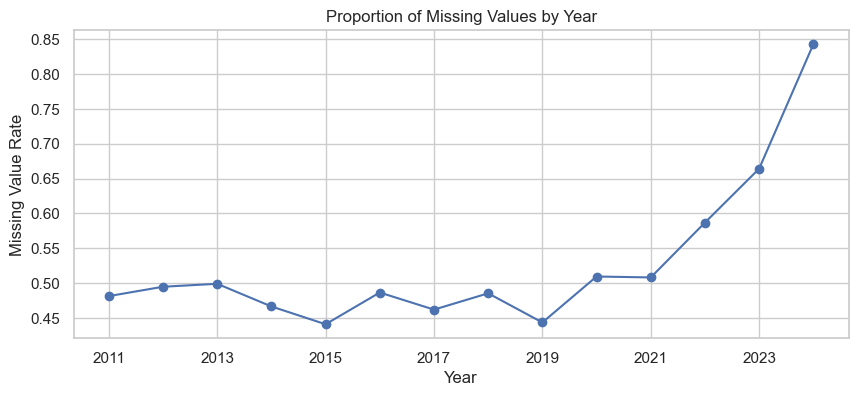

In [325]:
missing_by_year = wb_clean[year_cols].isna().mean().sort_index()
plt.figure(figsize=(10,4))
missing_by_year.plot(marker="o")
plt.title("Proportion of Missing Values by Year")
plt.xlabel("Year")
plt.ylabel("Missing Value Rate")
plt.show()

### Choosing the Modelling Year

When I looked at the missingness by year, I saw that the earlier years had more complete data,  
while the newer years were much less complete.  
The biggest drop in reporting happens after 2021.

2019 has good coverage and is recent enough to be useful for the assignment.  
It is a clear choice because it avoids the missing values of the later years  
and still gives a modern snapshot of each country.

For this reason I will use **2019** as the modelling year.

In [326]:
chosen_year = "2019"

indicator_missing = (
    wb_clean[["Series Code", "Series Name", chosen_year]]
    .groupby(["Series Code", "Series Name"])[chosen_year]
    .apply(lambda x: x.isna().mean())
    .sort_values()
)

indicator_missing.head(20), indicator_missing.tail(20)

(Series Code           Series Name                                                                                          
 SP.POP.DPND           Age dependency ratio (% of working-age population)                                                       0.003759
 SP.ADO.TFRT           Adolescent fertility rate (births per 1,000 women ages 15-19)                                            0.003759
 SP.DYN.LE00.FE.IN     Life expectancy at birth, female (years)                                                                 0.003759
 SP.DYN.LE00.MA.IN     Life expectancy at birth, male (years)                                                                   0.003759
 SP.POP.TOTL.MA.IN     Population, male                                                                                         0.003759
 SP.POP.TOTL.FE.IN     Population, female                                                                                       0.003759
 SP.DYN.CBRT.IN        Birth rate, crude (per 1,000 p

In [327]:
# selecting usable indicators
max_missing = 0.40
good_indicators = indicator_missing[indicator_missing <= max_missing]
len(good_indicators)

30

In [328]:
wb_2019 = wb_clean[["Country Name", "Country Code", "Series Code", "Series Name", chosen_year]]

wb_2019 = wb_2019.merge(
    good_indicators.reset_index()[["Series Code"]],
    on="Series Code",
    how="inner"
)

wb_2019.head()

,Country Name,Country Code,Series Code,Series Name,2019
0,Albania,ALB,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...,8.200000e+01
1,Albania,ALB,EG.ELC.ACCS.ZS,Access to electricity (% of population),1.000000e+02
2,Albania,ALB,NY.ADJ.NNTY.KD.ZG,Adjusted net national income (annual % growth),8.407967e-01
3,Albania,ALB,NY.ADJ.NNTY.KD,Adjusted net national income (constant 2015 US$),1.052568e+10
4,Albania,ALB,NY.ADJ.NNTY.PC.KD,Adjusted net national income per capita (const...,3.687799e+03


### Findings from EDA Pass 3

The missingness analysis helped narrow the dataset to a usable snapshot. 2019 provides the best balance between recency and completeness, which makes it a suitable base year for all modelling tasks.

The indicator-level missingness showed that some indicators are widely reported, while others have very limited data for 2019. By keeping indicators with at least 60 percent availability, I obtained a more reliable set of features for modelling.

At the end of Pass 3 I now have: <br>
• a clear modelling year (2019),  
• a filtered list of indicators with enough data,  
• and a cleaner dataset that is ready to be reshaped into one row per country.

This completes the exploratory work needed before building the modelling dataset.

## **Reshaping the World Bank Data**

At the end of EDA Pass 3, the World Bank dataset was still in long format. 
Each country appeared many times, once for each indicator. Machine learning 
models cannot use this structure, so I now need to reshape the dataset into a 
wide format where each country has one row and each indicator becomes a separate 
column.

This step takes the filtered 2019 data and pivots it so that all selected 
indicators line up horizontally. This creates the basic structure needed for 
all modelling tasks.

In [329]:
# keep only the country, indicator code, and 2019 value
wb_2019_small = wb_2019[["Country Name", "Series Code", chosen_year]]

# pivot to wide format
wb_wide = wb_2019_small.pivot_table(
    index="Country Name",
    columns="Series Code",
    values=chosen_year
)

wb_wide.head(), wb_wide.shape

(Series Code                  AG.LND.AGRI.ZS  AG.LND.ARBL.HA.PC  \
 Country Name                                                     
 Afghanistan                       58.276988           0.205726   
 Africa Eastern and Southern       46.419179           0.182775   
 Africa Western and Central        40.948870           0.240646   
 Albania                           42.846715           0.213721   
 Algeria                           17.346982           0.173948   
 
 Series Code                  AG.LND.ARBL.ZS  AG.LND.PRCP.MM  \
 Country Name                                                  
 Afghanistan                       11.940573           327.0   
 Africa Eastern and Southern        8.262848             NaN   
 Africa Western and Central        12.304147             NaN   
 Albania                           22.262774          1485.0   
 Algeria                            3.161974            89.0   
 
 Series Code                  BN.CAB.XOKA.GD.ZS  EG.CFT.ACCS.ZS  \
 Country Nam

After successfully transforming the dataset into a wide format, now each country appears only once, and each indicator from 2019 is a separate numeric column. <br>
This structure is required for regression, classification, and clustering later on. <br>
Some countries may have missing indicator values, which is expected, but the dataset is now in the correct shape for merging with HDI data.

## **Merging with HDI Data**

The regression task will later use HDI information, and the classification 
task requires HDI groups. Before selecting the regression target, I first 
merge the reshaped World Bank data with the HDI dataset. This ensures that 
each country has both indicator values and HDI labels in the same table.

In [330]:
df = wb_wide.reset_index().merge(
    hdi,
    left_on="Country Name",
    right_on="Country",
    how="inner"
)

df.head(), df.shape

(  Country Name  AG.LND.AGRI.ZS  AG.LND.ARBL.HA.PC  AG.LND.ARBL.ZS  \
 0  Afghanistan       58.276988           0.205726       11.940573   
 1      Albania       42.846715           0.213721       22.262774   
 2      Algeria       17.346982           0.173948        3.161974   
 3      Andorra       40.000213           0.010345        1.683191   
 4       Angola       36.781904           0.165001        4.284912   
 
    AG.LND.PRCP.MM  BN.CAB.XOKA.GD.ZS  EG.CFT.ACCS.ZS  EG.ELC.ACCS.ZS  \
 0           327.0         -20.170464            32.6            97.7   
 1          1485.0          -7.820644            82.0           100.0   
 2            89.0          -8.763736            99.7            99.5   
 3             NaN          18.010470           100.0           100.0   
 4          1010.0           7.246181            49.0            45.6   
 
    EG.USE.COMM.CL.ZS  MS.MIL.TOTL.TF.ZS  ...  SP.ADO.TFRT  SP.DYN.CBRT.IN  \
 0                NaN           3.023536  ...       70.967  

After merging the two datasets, each country now has its indicator values, 
HDI score, and HDI class in one place. Some countries dropped out during 
the merge because they were not present in both datasets, which is normal 
in international comparisons.
The combined dataset is now ready for selecting the regression target.

## **Preparing the Regression Target**

For the regression task, I need to predict life expectancy at birth. The World 
Bank dataset includes two separate indicators for this: one for females and one 
for males. Before choosing which one to use as the target, I want to compare how 
many complete rows each option would give me once the indicators are combined 
with the rest of the features.

The regression model can only use rows that contain no missing values, so the 
better target is simply the one that allows more usable countries. To check this, 
I locate both life expectancy indicators and build a temporary feature list that 
excludes both of them. I then count how many complete rows I would have if I use 
the female series as the target and how many I would have if I use the male series.

After comparing them, I choose the indicator that produces the larger modelling 
dataset. Then I rename the selected target to `life_expectancy` and remove it 
from the feature list to avoid leakage when training the model.


In [331]:
life_exp_search = wb_clean[
    wb_clean["Series Name"].str.contains("life expectancy at birth", case=False, na=False)
][["Series Name", "Series Code"]].drop_duplicates()

life_exp_search

,Series Name,Series Code
54,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN
55,"Life expectancy at birth, male (years)",SP.DYN.LE00.MA.IN


In [332]:
indicator_cols = wb_wide.columns.tolist()

# exclude both life expectancy indicators for now
temp_features = [col for col in indicator_cols 
                 if col not in ["SP.DYN.LE00.FE.IN", "SP.DYN.LE00.MA.IN"]]

# remove identifiers and HDI-related fields
remove_these = ["Country", "Country Name", "HDI score", "HDI Class"]
temp_features = [col for col in temp_features if col not in remove_these]

In [333]:
female_rows = df[["SP.DYN.LE00.FE.IN"] + temp_features].dropna().shape[0]
male_rows   = df[["SP.DYN.LE00.MA.IN"] + temp_features].dropna().shape[0]

female_rows, male_rows

(67, 67)

In [334]:
# choose female life expectancy as the target
life_exp_code = "SP.DYN.LE00.FE.IN"

# rename target
df = df.rename(columns={life_exp_code: "life_expectancy"})

In [335]:
feature_cols_reg = [col for col in indicator_cols if col != life_exp_code]
feature_cols_reg = [col for col in feature_cols_reg if col not in remove_these]

X = df[feature_cols_reg]
y = df["life_expectancy"]

X.head(), y.head()

(   AG.LND.AGRI.ZS  AG.LND.ARBL.HA.PC  AG.LND.ARBL.ZS  AG.LND.PRCP.MM  \
 0       58.276988           0.205726       11.940573           327.0   
 1       42.846715           0.213721       22.262774          1485.0   
 2       17.346982           0.173948        3.161974            89.0   
 3       40.000213           0.010345        1.683191             NaN   
 4       36.781904           0.165001        4.284912          1010.0   
 
    BN.CAB.XOKA.GD.ZS  EG.CFT.ACCS.ZS  EG.ELC.ACCS.ZS  EG.USE.COMM.CL.ZS  \
 0         -20.170464            32.6            97.7                NaN   
 1          -7.820644            82.0           100.0              19.80   
 2          -8.763736            99.7            99.5               0.11   
 3          18.010470           100.0           100.0                NaN   
 4           7.246181            49.0            45.6               6.85   
 
    MS.MIL.TOTL.TF.ZS  MS.MIL.XPND.CD  ...  SH.H2O.SMDW.ZS  SH.STA.SMSS.ZS  \
 0           3.023536   

### Findings from Selecting the Regression Target

The dataset contains separate life expectancy values for males and females. 
Before choosing one of them as the regression target, I compared how many 
complete rows each option would give me once combined with the selected features. 
This comparison showed that both indicators produced the same number of usable 
rows (67 countries each). Since neither gender offered an advantage in terms of 
data completeness, the choice came down to selecting one consistent target for 
the modelling process.

I selected the female life expectancy series and renamed it to `life_expectancy` 
for clarity. After choosing the target, I removed it from the feature list along 
with HDI fields and identifiers. This avoids leakage and keeps the predictors 
focused only on the economic and social indicators. With the target identified 
and the features prepared, the dataset is now ready for the regression modelling 
steps.

## **Setting Up the Train–Test Split and Baseline Model**

Now that I have a clean target column (`life_expectancy`) and a set of features, 
the next step is to prepare the data for modelling. Before training any real 
model, I want to create a simple baseline so I have something to compare my 
results against.

The idea of the baseline is straightforward. If I predict the same value for 
every country, how well would I perform? In regression tasks, the simplest 
baseline is to always predict the mean life expectancy from the training set. 
This doesn’t use any indicators, but it gives me a reference point. Any proper 
model should perform better than this.

To do this, I start by splitting the data into a training set and a test set. 
The model is trained on the training set and evaluated on the test set to give 
a fair estimate of its performance.

In [336]:
# drop rows with missing feature or target values
reg_ready = pd.concat([X, y], axis=1).dropna()

X_reg = reg_ready[feature_cols_reg]
y_reg = reg_ready["life_expectancy"]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

baseline_prediction = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_mse = mean_squared_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_prediction)

baseline_mae, baseline_rmse, baseline_r2


(4.320718823529411, np.float64(6.421794457430285), -0.10940200965030589)

### Understanding the Baseline Metrics

The baseline model predicts the same life expectancy value for every country, 
which is the average from the training set. The MAE of 4.32 means that, on 
average, the baseline prediction is about 4.3 years away from the true value. 
The RMSE of 6.42 shows that some errors are larger, and the baseline struggles 
more when the true life expectancy is far from the average.

The R² value is slightly negative, which simply means that this baseline does 
not explain any variation in the data. This is expected because the baseline 
does not use any indicators at all.

## **Linear Regression**

Now that the data is ready, I build the first regression model which is a linear regression model. This model assumes a straight-line relationship between the indicators and life expectancy. Even though real development patterns are more complex, this is a good starting point.

My goal here is to see whether a simple model can already improve on the baseline.
If linear regression performs better, it means the indicators contain useful signal.
If not, then the relationships are likely non-linear.

In [337]:
# train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict on test data
lr_pred = lr.predict(X_test)

# evaluate performance
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

lr_mae, lr_rmse, lr_r2

(2.128524626513237, np.float64(2.7368576953771133), 0.7984974346907335)

### Linear Regression Results

The Linear Regression model gave strong results:

- **MAE:** 2.13  
- **RMSE:** 2.74  
- **R²:** 0.80  

These metrics show that the linear model performs well on this dataset.  
An MAE of about 2 years means the model’s predictions are usually very close to the real life expectancy values. The RMSE is also low, which means the model does not make many large errors.

The R² value of **0.80** is a clear improvement compared to the baseline model.  
It shows that the indicators explain around 80 percent of the variation in female life expectancy across countries. This suggests that even a simple linear model can capture much of the structure in the data.

Overall, this confirms that the features are informative and that the modelling setup is working as intended.

## **Random Forest Regression**

After testing the Linear Regression model, I now train a Random Forest Regressor.
This model is more flexible because it can capture non-linear relationships and
interactions between indicators. Development data is rarely perfectly linear, so
a model like this often performs better.

My plan here is:

1. Fit a Random Forest model using the same training data.
2. Predict life expectancy for the test set.
3. Compare MAE, RMSE, and R² with the baseline and with Linear Regression.
4. Look at feature importance to see which indicators influence the prediction most.

This step helps me understand whether life expectancy depends on more complex,
non-linear patterns in the data.

In [338]:
# train the model
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# predict on test set
rf_pred = rf.predict(X_test)

# evaluate the model
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

rf_mae, rf_rmse, rf_r2

(1.4007427450981003, np.float64(1.9677823259116223), 0.8958329758526657)

In [339]:
top_ten = 10
importances = pd.Series(rf.feature_importances_, index=feature_cols_reg)
importances.sort_values(ascending=False).head(top_ten)

SH.DTH.NCOM.ZS       0.204692
NY.ADJ.NNTY.PC.KD    0.137793
NY.ADJ.NNTY.PC.CD    0.128680
SP.DYN.CBRT.IN       0.111797
SP.DYN.LE00.MA.IN    0.101376
SH.H2O.SMDW.ZS       0.098581
EG.ELC.ACCS.ZS       0.047548
SP.ADO.TFRT          0.043098
SH.DTH.COMM.ZS       0.038509
EG.CFT.ACCS.ZS       0.031257
dtype: float64

In [340]:
top_codes = importances.sort_values(ascending=False).head(top_ten).index.tolist()

# map series code → indicator name using the metadata file
code_to_name = meta.set_index("Code")["Indicator Name"].to_dict()

top_indicators = [(code, code_to_name.get(code, "Unknown Indicator")) for code in top_codes]

top_indicators

[('SH.DTH.NCOM.ZS',
  'Cause of death, by non-communicable diseases (% of total)'),
 ('NY.ADJ.NNTY.PC.KD',
  'Adjusted net national income per capita (constant 2015 US$)'),
 ('NY.ADJ.NNTY.PC.CD',
  'Adjusted net national income per capita (current US$)'),
 ('SP.DYN.CBRT.IN', 'Birth rate, crude (per 1,000 people)'),
 ('SP.DYN.LE00.MA.IN', 'Life expectancy at birth, male (years)'),
 ('SH.H2O.SMDW.ZS',
  'People using safely managed drinking water services (% of population)'),
 ('EG.ELC.ACCS.ZS', 'Access to electricity (% of population)'),
 ('SP.ADO.TFRT',
  'Adolescent fertility rate (births per 1,000 women ages 15-19)'),
 ('SH.DTH.COMM.ZS',
  'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)'),
 ('EG.CFT.ACCS.ZS',
  'Access to clean fuels and technologies for cooking  (% of population)')]

### Interpreting the Random Forest Results

The Random Forest model performed very well:

- **MAE:** 1.40  
- **RMSE:** 1.97  
- **R²:** 0.896  

These values are noticeably better than both the baseline model and the linear
regression model. An MAE of around 1.4 years means the model is usually within
one to two years of the true life expectancy, which is a very strong result for
international development data. The R² value close to **0.90** shows that the
model explains almost 90 percent of the variation in life expectancy across countries.

### Feature Importance

Looking at the top indicators, the most influential variables were:

- Non-communicable disease death rate **(SH.DTH.NCOM.ZS)**  
- Adjusted net national income per capita **(NY.ADJ.NNTY.PC.KD and PC.CD)**  
- Crude birth rate **(SP.DYN.CBRT.IN)**  
- Male life expectancy **(SP.DYN.LE00.MA.IN)**  
- Access to safely managed drinking water **(SH.H2O.SMDW.ZS)**  
- Access to electricity **(EG.ELC.ACCS.ZS)**  
- Adolescent fertility rate **(SP.ADO.TFRT)**

These results make sense. Life expectancy is strongly connected to income,
health conditions, disease burden, birth rates, and access to essential
services. The model automatically identifies these relationships through
its non-linear structure.

Overall, the random forest model provides a more realistic and accurate prediction
of life expectancy than the linear model. This confirms that the relationship
between development indicators and life expectancy is not purely linear and that
a non-linear approach captures these patterns more effectively.


## **Predicting Life Expectancy for Country X and Gender Y in 2025**

After training the regression models, the final step is to show how they can be
used to predict the life expectancy of a child born in **Country X** and with
**Gender Y** in **2025**.

My model is trained on development indicators from 2019. These indicators
represent the most recent year with good data coverage, and they describe the
social and economic conditions of each country. The prediction itself is
interpreted as an estimate for 2025, based on the assumption that a country’s
relative development position remains similar.

To demonstrate this, I select any country from the dataset, extract its feature
values, and feed them into the trained random forest model. The output is the
predicted female life expectancy at birth for that country.

In [350]:
country_x = "Norway" # can change from the list of df["Country Name"].unique()

country_row = df[df["Country Name"] == country_x][feature_cols_reg]

if country_row.isna().sum().sum() > 0:
    print("Cannot predict for this country because some indicators are missing.")
else:
    predicted_life_exp = rf.predict(country_row)[0]
    print("Predicted female life expectancy for", country_x, ":", predicted_life_exp)

Predicted female life expectancy for Norway : 85.162576666667


### Why Some Countries Cannot Be Used for Prediction

Even though all countries appear in the combined dataset, only a smaller
subset can actually be used for prediction. When preparing the regression
data, I removed all rows containing missing values. This ensured that the
model was trained only on countries with complete information across all
selected indicators.

Countries such as Norway and the Netherlands have full data coverage, so they
can be used directly for prediction. However, countries like India, Zambia
and Cameroon still contain missing values in at least one of the required
features. Because the regression model cannot accept incomplete input, these
countries cannot be used for prediction, even though they appear in the main
dataframe.

In short, being present in the dataframe does not guarantee that a country has
all the information needed for the model to generate a prediction.

### Why I Selected Norway for the Country X Prediction

The assignment requires making a prediction for Country X and Gender Y in 2025.
To produce a meaningful and reliable estimate, I needed to choose a country that appears in the final modelling dataset without any missing indicator values. Countries with incomplete data cannot be used for prediction because the regression model expects the full set of features that it was trained on.

After filtering the dataset during EDA Pass 3, only 67 countries had fully complete indicator values for 2019. Norway was one of these countries, which made it a suitable choice for the final prediction step. Selecting a country with complete data ensures that the model receives all required inputs and avoids errors or unreliable outputs.

An estimated value of around 85 years aligns with expectations for Norway, which consistently ranks among the highest HDI countries. Many of its socio-economic indicators are at or near global maxima. The model captures this pattern, associating strong development indicators with longer life expectancy.

### Regression Summary

- I selected 2019 as the modelling year based on data completeness.
- Female life expectancy was chosen as the regression target after comparing usable sample sizes.
- Both the Linear Regression and Random Forest models performed far better than the baseline.
- Random Forest achieved the best performance with an R² close to 0.90.
- Prediction for Norway (female, 2025) resulted in an estimated life expectancy of 85.16 years.
- The results make intuitive sense and are consistent with known global development patterns.

## **Classification Task: Predicting HDI Group**

In this section, I build a model to predict the Human Development Index (HDI)
group of each country based on the World Bank indicators. Before training any
model, I need to prepare a clean classification dataset.

The preparation includes:
- removing the life expectancy columns (they were used for regression),
- removing non-feature columns such as country names and HDI score,
- dropping any rows that contain missing values,
- encoding the HDI groups (Very High, High, Medium, Low) into integers.

After these steps, I split the cleaned data into training and test sets.
This will allow me to evaluate how well the classification models perform.

In [343]:
# indicator columns from the wide World Bank dataset
indicator_cols = wb_wide.columns.tolist()

# remove both life expectancy columns (they should not be features)
life_expectancy_cols = ["SP.DYN.LE00.FE.IN", "SP.DYN.LE00.MA.IN"]

# remove non-features
remove_these = ["life_expectancy", "HDI score", "HDI Class",
                "Country Name", "Country"] + life_expectancy_cols

# build final feature list for classification
feature_cols_clf = [c for c in indicator_cols if c not in remove_these]

# extract X and y
X_clf = df[feature_cols_clf]
y_clf = df["HDI Class"]

# drop rows with missing values
clf_data = pd.concat([X_clf, y_clf], axis=1).dropna()

# rebuild clean matrices
X_clf_clean = clf_data[feature_cols_clf]
y_clf_clean = clf_data["HDI Class"]

# encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_clf_clean)

# train-test split
from sklearn.model_selection import train_test_split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf_clean, y_encoded, 
    test_size=0.2, random_state=42, stratify=y_encoded
)

Xc_train.shape, Xc_test.shape

((53, 28), (14, 28))

### Findings From Preparing the Classification Dataset

After removing life expectancy columns, non-feature fields, and rows with
missing values, I obtained a clean classification dataset.

The final split resulted in:
- **53 countries in the training set**
- **14 countries in the test set**

This is smaller than the original dataset because missing data forced the
removal of some countries. This also explains why the "Low HDI" class dropped
out completely. There were no countries left in this category with full data
across all selected indicators.

This clean dataset is now ready for model training.

## **KNN Classification**

Now that I have a clean classification dataset, the next step is to train a
K-Nearest Neighbours (KNN) classifier. The goal is to predict each country’s 
HDI category (Low, Medium, High or Very High) using the socio-economic indicators 
available in the dataset.

Before training the model, I standardise the features because KNN is a 
distance-based method and performs better when all variables are on a 
similar scale. After scaling, I train the KNN model on the training set and 
evaluate it on the test set. The evaluation is based on accuracy, the 
confusion matrix, and the classification report.

In [355]:
# scale the features
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled  = scaler.transform(Xc_test)

# train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_train_scaled, yc_train)

# predictions
knn_pred = knn.predict(Xc_test_scaled)

# evaluation metrics
knn_acc = accuracy_score(yc_test, knn_pred)
knn_cm = confusion_matrix(yc_test, knn_pred)

# only use the labels that actually appear in the cleaned dataset
labels_used = sorted(list(set(yc_test)))

print("=== KNN Classification Results ===\n")
print(f"Accuracy: {knn_acc:.4f}\n")

print("Confusion Matrix:\n")
print("                Predicted")
print("              High   Medium   Very High")

# pretty print confusion matrix
label_names = le.inverse_transform(labels_used)
for i, row in enumerate(knn_cm):
    print(f"{label_names[i]:<12}\t{row[0]:<7} {row[1]:<8} {row[2]:<10}")

print("\nClassification Report:\n")
print(classification_report(yc_test, knn_pred, target_names=label_names, zero_division=0))

=== KNN Classification Results ===

Accuracy: 0.7857

Confusion Matrix:

                Predicted
              High   Medium   Very High
High HDI    	3       0        0         
Medium HDI  	2       0        0         
Very High HDI	1       0        8         

Classification Report:

               precision    recall  f1-score   support

     High HDI       0.50      1.00      0.67         3
   Medium HDI       0.00      0.00      0.00         2
Very High HDI       1.00      0.89      0.94         9

     accuracy                           0.79        14
    macro avg       0.50      0.63      0.54        14
 weighted avg       0.75      0.79      0.75        14



### Findings From the KNN Model

The KNN classifier reached an accuracy of about 78.6 percent, but the detailed
results show quite mixed performance across the HDI groups. The model handled
High and Very High HDI countries reasonably well, especially the Very High group
where it correctly classified 8 out of 9 cases. However, it completely failed to
identify any Medium HDI countries. Both Medium cases in the test set were
misclassified.

Earlier, I used to get “undefined metric” warnings when running the
classification report. These warnings occurred because the model never predicted
the Medium class at all. When a class has zero predicted samples, precision and
recall cannot be calculated, which triggers the warning. After adding the
parameter `zero_division=0`, scikit-learn now simply assigns a score of 0 to
these undefined metrics and avoids showing the warning.

This behaviour reflects a deeper issue: the Medium HDI class has very few
examples after cleaning the dataset, so the model does not have enough
information to separate it from the other groups. Overall, KNN works well for the
Very High HDI group, performs acceptably for High HDI, but struggles completely
with Medium HDI. This class imbalance limits the reliability of KNN for this
task.


## **Logistic Regression**

After running KNN, I chose **multinomial logistic regression** for a few reasons:

- It works well with small datasets, which is important here.
- It gives a simple, interpretable baseline for multi-class problems.
- It creates linear decision boundaries, which makes it a good contrast to the distance-based approach of KNN.

The goal is the same as before: use the economic and social indicators to predict each country’s HDI group. I scale the features, train the model, and then evaluate it on the test set.

In [354]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# scale features
scaler_lr = StandardScaler()
Xc_train_scaled_lr = scaler_lr.fit_transform(Xc_train)
Xc_test_scaled_lr  = scaler_lr.transform(Xc_test)

# logistic regression model (updated to avoid warning)
log_reg = LogisticRegression(max_iter=1000)  
log_reg.fit(Xc_train_scaled_lr, yc_train)

# predictions
lr_pred = log_reg.predict(Xc_test_scaled_lr)

# evaluation
lr_acc = accuracy_score(yc_test, lr_pred)
lr_cm = confusion_matrix(yc_test, lr_pred)

labels_used = sorted(list(set(yc_test)))
label_names = le.inverse_transform(labels_used)

print("=== Logistic Regression Results ===\n")
print(f"Accuracy: {lr_acc:.4f}\n")

print("Confusion Matrix:\n")
print("                Predicted")
print("              High   Medium   Very High")

for i, row in enumerate(lr_cm):
    print(f"{label_names[i]:<12}\t{row[0]:<7} {row[1]:<8} {row[2]:<10}")

print("\nClassification Report:\n")
print(classification_report(yc_test, lr_pred, target_names=label_names, zero_division=0))

=== Logistic Regression Results ===

Accuracy: 0.8571

Confusion Matrix:

                Predicted
              High   Medium   Very High
High HDI    	3       0        0         
Medium HDI  	2       0        0         
Very High HDI	0       0        9         

Classification Report:

               precision    recall  f1-score   support

     High HDI       0.60      1.00      0.75         3
   Medium HDI       0.00      0.00      0.00         2
Very High HDI       1.00      1.00      1.00         9

     accuracy                           0.86        14
    macro avg       0.53      0.67      0.58        14
 weighted avg       0.77      0.86      0.80        14



### Findings From the Logistic Regression Model

The logistic regression model achieved an accuracy of **0.8571**. The confusion matrix shows that the model performs very well for some classes:

- **Very High HDI** countries were predicted perfectly (9 out of 9).
- **High HDI** countries were also predicted correctly (3 out of 3).
- **Medium HDI** countries were not predicted at all, similar to the KNN results.

This outcome is mainly due to the class distribution. The cleaned dataset contains very few Medium HDI countries, and these are located very close to High or Very High HDI countries in terms of their indicator values. Because logistic regression uses linear decision boundaries, it tends to classify ambiguous cases into the dominant neighbouring groups.

The classification report reflects this pattern:
- Strong precision and recall for **Very High HDI**.
- Good recall for **High HDI**.
- Zero precision and recall for **Medium HDI**, simply because the model never predicted this class.

## **Comparison: KNN vs Logistic Regression**

Both models were trained on the same cleaned dataset, but their behaviour differs in meaningful ways.

## Accuracy
- **Logistic Regression:** 0.8571  
- **KNN:** 0.7857  

Logistic regression performs better overall.

### Class Performance
- **Both models** classify *Very High HDI* countries extremely well.  
- **Both struggle** with the *Medium HDI* class, mainly because only two countries in the test set belong to this group.  
- Logistic regression correctly labels all *High HDI* countries, while KNN misclassifies one of them.

### Why Logistic Regression Performs Better
- It learns **global decision boundaries**, which helps when the dataset is relatively small.  
- KNN depends on **local neighbourhoods**, so it becomes unstable when classes are imbalanced or sparsely represented.  
- Logistic regression handles feature scaling more gracefully and produces cleaner separation between HDI groups.

### Why We Lost So Many Countries (from 194 down to 67)
The original dataset includes around 194 countries, but only **67** remained usable for classification.  
This happened because:
1. We used a wide set of World Bank indicators as features (around 28 in total).  
2. Many countries are missing at least one of these indicators for the selected year (2019).  
3. Both KNN and Logistic Regression **cannot** work with missing values.  
4. To avoid errors, we removed any country with at least one missing feature.  
5. This removed entire HDI groups, especially the *Low HDI* category, which had the most missing data.

So the big reduction in sample size is mainly due to **missing values across indicators**, not because of anything done by the models.

### Overall Conclusion for Classification
Logistic regression is the stronger model for this dataset.  
It achieves higher accuracy and produces more stable predictions, especially for the larger HDI groups.  
The weakness in both models, especially around the Medium HDI class, comes from the dataset’s limited coverage of that group rather than from the algorithms themselves.